In [82]:
import numpy as np
from scipy.fftpack import dct, idct
import matplotlib.pyplot as plt
from PIL import Image

In [83]:
# img = plt.imread("barbara_gray.bmp")
img_pil = Image.open("barbara_gray.bmp")
print(img_pil.size, img_pil.format, img_pil.mode)
img = np.array(img_pil)
print(img[0:4,0:4])
# Image._show(img)

height, width = img.shape[0], img.shape[1]
# plt.imshow(img, cmap='gray')
# print(img.dtype)
P = 10
u1 = 4 
v1 = 5 
u2 = 5 
v2 = 4 # coefficients for embedding (4,5), (5,4)

(512, 512) BMP L
[[220 229 230 227]
 [206 228 229 225]
 [212 227 226 221]
 [221 229 225 220]]


In [84]:
def dct8x8(block):
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

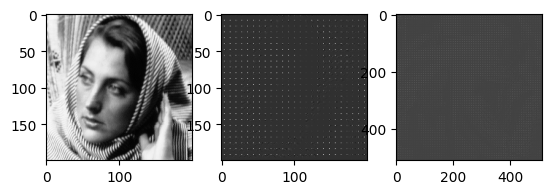

In [85]:
dct_image = np.zeros((height, width))
for i in range(0, height, 8):
    for j in range(0, width, 8):
        block = img[i:i+8, j:j+8]
        dct_image[i:i+8, j:j+8] = dct8x8(block)

plt.subplot(1, 3, 1)
plt.imshow(img[0:200, 300:500], cmap="gray")
plt.subplot(1, 3, 2)
plt.imshow(dct_image[0:200, 300:500], cmap="gray")
plt.subplot(1, 3, 3)
plt.imshow(dct_image, cmap="gray")

## Embedding message

In [86]:
class LFSRGenerator:
    def __init__(self, seed, bits=16, taps = None):
        self.state = seed & ((1 << bits) - 1)
        self.bits = bits
        self.mask = (1 << bits) - 1
        # primitive polynome x^16 + x^14 + x^13 + x^11 + 1
        if taps == None:
            self.taps = [12, 6, 4, 1]#829
        else:
            self.taps = taps
        self.original_state = self.state

    def reset(self):
        self.state = self.original_state
    
    def next_bit(self):
        output = self.state & 1
        feedback = 0
        for tap in self.taps:
            feedback ^= (self.state >> (tap -1)) & 1

        self.state = (self.state << 1) | (feedback)# << (self.bits -1))
        self.state = self.state & self.mask
        # return output

    def get_bits(self, count):
        return [self.next_bit() for _ in range(count)]
    
    def get_int(self):
        self.next_bit()
        return self.state
        
lfsr = LFSRGenerator(seed=0xFD2A, bits=12)
# print(lfsr.state)
# index = lfsr.get_int()
# print(index)
# print(lfsr.state)

    # print(lfsr.state)


In [87]:
data = np.zeros(2**12)
for i in range(2**12):
    data[i] = lfsr.get_int()
    if i % 200 == 0:
        print(i)

0
200
400
600
800
1000
1200
1400
1600
1800
2000
2200
2400
2600
2800
3000
3200
3400
3600
3800
4000


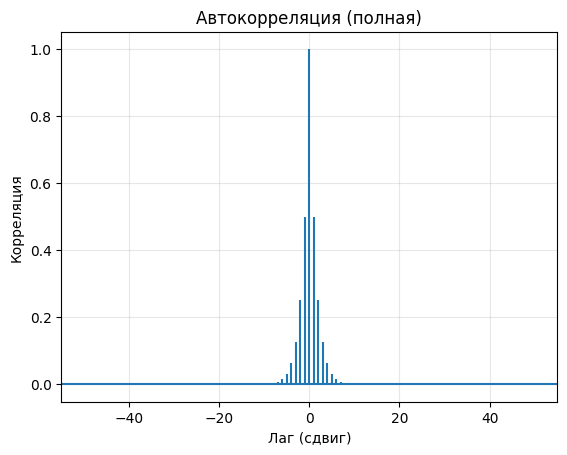

In [88]:
# Встроенная функция автокорреляции matplotlib
# Она сразу показывает и отрицательные, и положительные лаги
plt.acorr(data - np.mean(data), maxlags=50, normed=True)
plt.title('Автокорреляция (полная)')
plt.xlabel('Лаг (сдвиг)')
plt.ylabel('Корреляция')
plt.grid(True, alpha=0.3)
plt.show()

In [89]:
def adjust_coeffs(block, bit):

    k1 = block[u1, v1]
    k2 = block[u2, v2]
    # print(k1, k2, end='\n')
    # if bit == 1 |k1| >= |k2| + P
    # if bit == 0 |k2| >= |k1| + P
    if(bit == 1):
        if abs(k1) >= abs(k2) + P:
            return block
        if abs(k1) + abs(k2) == 0:
            new_k1 = P+1
            new_k2 = 1
        else:
            avg = (abs(k1) + abs(k2))/2
            new_abs_k1 = avg + P/2
            new_abs_k2 = avg - P/2

            new_k1 = new_abs_k1 * np.sign(k1) if k1 != 0 else new_abs_k1
            new_k2 = new_abs_k2 * np.sign(k2) if k2 != 0 else new_abs_k2

            if abs(new_k1) < abs(new_k2) + P:
                new_k1 = (abs(new_k2) + P)*np.sign(new_k1)
    else:
        if abs(k2) >= abs(k1) + P:
            return block
        if abs(k1) + abs(k2) == 0:
            new_k1 = 1
            new_k2 = P + 1
        else:
            avg = (abs(k1) + abs(k2))/2
            new_abs_k1 = avg - P/2
            new_abs_k2 = avg + P/2

            new_k1 = new_abs_k1 * np.sign(k1) if k1 != 0 else new_abs_k1
            new_k2 = new_abs_k2 * np.sign(k2) if k2 != 0 else new_abs_k2

            if abs(new_k2) < abs(new_k1) + P:
                new_k2 = (abs(new_k1) + P)*np.sign(new_k2)
    # print(new_k1, new_k2)
    block[u1, v1] = new_k1
    block[u2, v2] = new_k2
    # print(block[u1, v1])
    # print(block[u2, v2])
    return block

In [90]:
message = "BSUIR"
binary_message = ''.join(format(ord(char), '08b') for char in message)
message_len = len(binary_message)
print(binary_message)
print(message_len)

binary_message += '00000000'
bit_index = 0

lfsr.reset()

for i in range(len(binary_message)):
    block_index = lfsr.get_int()
    row = int(block_index // (dct_image.shape[0]/8))
    col = int(block_index % (dct_image.shape[1]/8))
    print(row, col)
    block = dct_image[row*8:(row+1)*8, col*8:(col+1)*8]
    current_bit = int(binary_message[bit_index])
    print(block[u1, v1], block[u2, v2])
    dct_image[row*8:(row+1)*8, col*8:(col+1)*8] = adjust_coeffs(block, current_bit)
    bit_index += 1
    print(block[u1, v1], block[u2, v2])
# for i in range(0, height, 8):
#     for j in range(0, width, 8):
#         if bit_index >= len(binary_message):
#             break
#         block_index = lfsr.get_int()
#         # block = dct_image[i:i+8,j:j+8]
#         current_bit = int(binary_message[bit_index])
#         # block = adjust_coeffs(block, current_bit)
#         # np.set_printoptions(precision=1)
#         print(bit_index)
#         # print("1 ", block)
#         dct_image[i:i+8, j:j+8] = adjust_coeffs(block, current_bit)
#         print(block[u1, v1], block[u2, v2])
#         # print("2 ",dct_image[i:i+8, j:j+8])
#         bit_index += 1


0100001001010011010101010100100101010010
40
41 21
1.308809011621547 -0.12862588038290151
-4.281282553997776 -14.281282553997777
18 42
-13.142888056324383 28.505520799846423
-25.8242044280854 15.824204428085402
37 20
0.2830681319989174 -0.18686224613599914
-4.7650348109325416 -14.76503481093254
10 41
14.773957042319047 0.8222340038041343
2.7980955230615905 12.79809552306159
21 19
0.559932693443078 -0.37031399707858154
-4.53487665473917 -14.53487665473917
42 39
45.831841668904474 1.4252470790637906
18.62854437398413 28.62854437398413
21 15
-5.867227451172643 -6.26399433281427
-11.065610891993456 -1.0656108919934564
42 30
9.565300615239343 -21.13282341726513
9.565300615239343 -21.13282341726513
20 60
2.633231612584746 7.005184379018307
-0.18079200419847297 10.180792004198473
41 56
-4.098830006528666 -5.561184969918206
-10.169992511776563 0.16999251177656394
19 49
5.5677271150037 -0.25166574597005825
-2.0903035695131207 -12.090303569513122
39 34
12.31203324534155 -25.43921219494742
23.8756

220


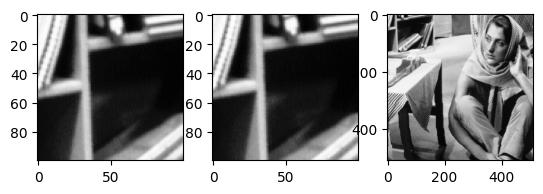

In [91]:
stego_image = np.zeros_like(img)
for i in range(0, height, 8):
    for j in range(0, width, 8):
        block = dct_image[i:i+8, j:j+8]
        stego_image[i:i+8, j:j+8] = idct(idct(block.T, norm='ortho').T, norm='ortho')
print(stego_image[0,0])
stego_pil = Image.fromarray(stego_image)
stego_pil.save('stego_image.bmp')
# plt.imsave("stego_image.bmp", stego_image, cmap="gray" )
plt.subplot(1, 3, 1)
plt.imshow(img[0:100, 0:100], cmap="gray")
plt.subplot(1, 3, 2)
plt.imshow(stego_image[0:100, 0:100], cmap="gray")
plt.subplot(1, 3, 3)
plt.imshow(stego_image, cmap="gray")

## Extracting message

In [95]:
# stego_image = plt.imread("stego_image.bmp")
stego_pil = Image.open("stego_image.bmp")
stego_image = np.array(stego_pil)
print(stego_image[0,0])
extracted_bits = []
bytes_array = []
lfsr.reset()
byte = 1
while(byte != 0):
    for i in range(8):
        block_index = lfsr.get_int()
        row = int(block_index // (stego_image.shape[0]/8))
        col = int(block_index % (stego_image.shape[1]/8))
        print(row, col)
        block = stego_image[row*8:(row+1)*8, col*8:(col+1)*8]
        block = dct8x8(block)
        k1 = abs(block[u1, v1])
        k2 = abs(block[u2, v2])
        print(k1, k2)
        if k1 >= k2 + P:
            bit = 1
        elif k2 >= k1 + P:
            bit = 0
        else:
            # Если условие не выполняется четко, используем простое сравнение
            bit = 1 if k1 >= k2 else 0 
        extracted_bits.append(bit)
    
    byte = 0
    for bit in extracted_bits:
        byte = (byte << 1) | bit
    print(byte)
    bytes_array.append(byte)
    extracted_bits.clear()
# for i in range(0, height, 8):
#     for j in range(0, width, 8):
#         block = stego_image[i:i+8, j:j+8]
#         block = dct8x8(block)
#         k1 = abs(block[u1, v1])
#         k2 = abs(block[u2, v2])
#         print(k1, k2)
#         if k1 >= k2 + P:
#             bit = 1
#         elif k2 >= k1 + P:
#             bit = 0
#         else:
#             # Если условие не выполняется четко, используем простое сравнение
#             bit = 1 if k1 >= k2 else 0
#         print(bit)
#         extracted_bits.append(bit)
# print(extracted_bits)
# bytes_array = []
# for i in range(0, len(extracted_bits), 8):
#     if i+8 > len(extracted_bits):
#         break
#     byte_bits = extracted_bits[i:i+8]
#     byte = 0
#     for bit in byte_bits:
#         byte = (byte << 1) | bit
#     bytes_array.append(byte)
message_dec = ''
for byte in bytes_array:
    if byte == 0:
        break
    message_dec += chr(byte)

print(message_dec)


220
41 21
4.770570265658014 14.497856932123385
18 42
26.07156656162251 15.57684229454829
37 20
5.207039926490318 14.902853259207022
10 41
2.9764000391579097 12.619791006965272
21 19
4.779839143312395 14.029841342062957
42 39
19.093299596888215 28.163789151080053
21 15
11.072125209894878 1.0590965740920362
42 30
9.565300615239343 21.13282341726513
66
20 60
0.46183022645614535 10.082713211499797
41 56
10.466495195183459 0.09964722761630158
19 49
2.2778195371186216 11.959102771380326
39 34
24.109590248502684 13.64165519178628
15 4
2.0893849365626287 11.323076073299518
30 8
3.5020930839828868 13.632032514034309
60 17
10.360437999237831 0.42832736311632924
56 34
12.49368430344358 2.0765155102125226
83
49 4
0.8459843614539078 10.152576374735071
34 9
32.69446873642694 2.5264245224540507
4 19
2.6634316958546336 12.375249627277134
8 39
11.533225350439455 0.3526320590526965
17 14
4.283308168668823 14.37273925514561
34 29
12.293335681552877 2.354230139399438
4 59
3.1963626696189555 13.31758036944